## 비행동역학 및 제어HW5(12210472 양동훈)

In [148]:
import numpy as np
from matplotlib import pyplot as plt

In [149]:
def runge_kutta4(f, tspan, y0, h):
    
    t = np.arange(tspan[0], tspan[1], h)
    t = np.insert(t, len(t), tspan[1])

    y = np.empty((len(t), len(y0))) 
    y[0] = y0

    for i, ti in enumerate(t):
        if i < len(t) - 1:           
            k1 = f(ti,           y[i])
            k2 = f(ti + 1/2*h,   y[i] + 1/2*k1*h)
            k3 = f(ti + 1/2*h,   y[i] + 1/2*k2*h)
            k4 = f(ti + h,       y[i] + k3*h)
            y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6

    return t, y

## Assumption and Initial Condition

Assumption
- Constant speed(No drag)
- Acceleration normal to velocity

Initial Condition

- $V = V_0 = 200m/s$
- $x_0 = y_0 = 0 $
- ${\psi_0} = 0$ 
- $a = 50 m/s^2$


## Rectangular formulation

$ \dot{x} = V_x , x(0) = x_0 \\$
$ \dot{y} = V_y , y(0) = y_0 \\ $
$\dot{V_x} = acos{\psi}, V_x(0) = Vsin{\psi_0}\\$
$\dot{V_y} = -asin{\psi}, V_y(0) = Vcos{\psi_0}\\$
$\text{where}\: \psi = tan^{-1}\frac{V_x}{V_y}$

In [150]:
def make_f(u):
    def f(t, x):
        [Px, Py, Vx, Vy] = x
        a = u

        psi = np.arctan2(Vx, Vy)
        if psi < 0:
            psi += 2 * np.pi

        Vx_dot = a * np.cos(psi)
        Vy_dot = -a * np.sin(psi)

        return np.array([Vx, Vy, Vx_dot, Vy_dot])
    return f

In [151]:
psi0 = 0 #deg
Px0 = 0
Py0 = 0 
V = 200 #m/s
V_x0 = V*np.sin(psi0)
V_y0 = V*np.cos(psi0)
a = 50 #m/s^2
x0 = np.array([Px0, Py0, V_x0, V_y0])

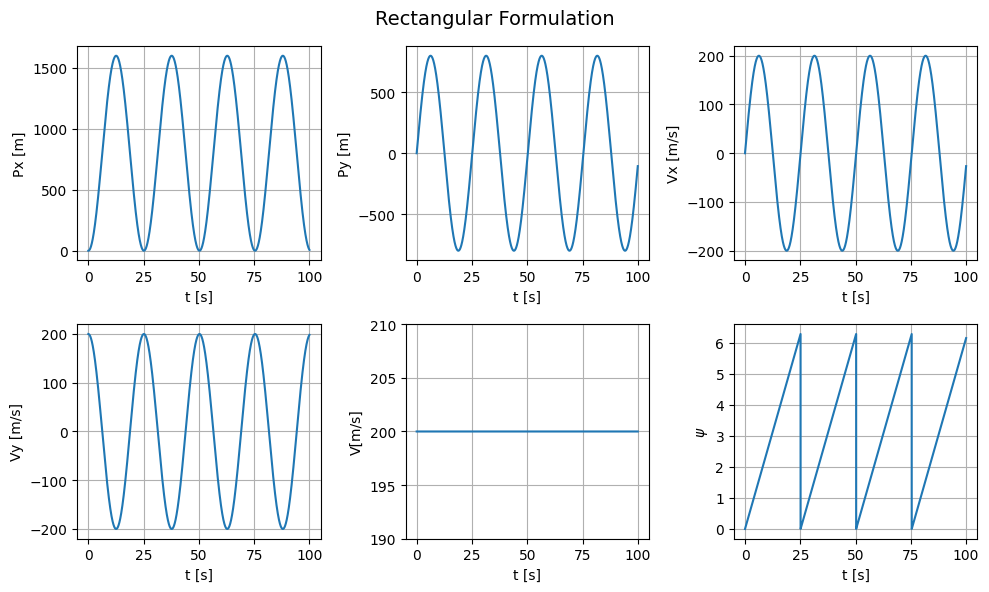

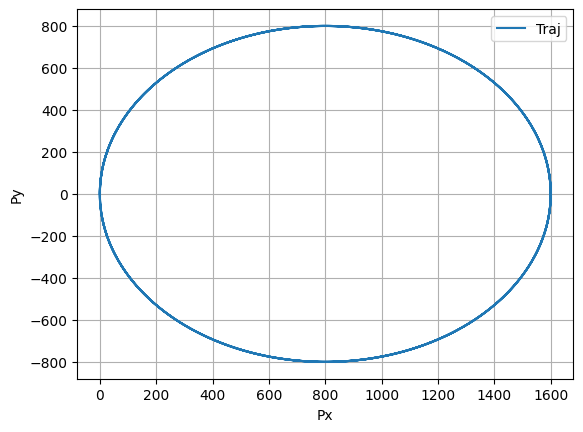

In [152]:
dt = 0.01
T  = 100.0


# --- 시뮬레이션 루프 ---
X = np.zeros((len(t), 4))
X[0] = x0
f = make_f(a)
t, y = runge_kutta4(f, [0, T], x0, dt)

# 결과 추출
Px = y[:, 0]
Py = y[:, 1]
Vx = y[:, 2]
Vy = y[:, 3]

psi = np.arctan2(Vx, Vy)

total_V = np.zeros(Vx.shape[0])
for i in range(Vx.shape[0]) :
     total_V[i] = np.sqrt(Vx[i]**2+ Vy[i]**2)
for i in range(psi.shape[0]) :
    if psi[i] < 0:
            psi[i] += 2 * np.pi



# 플롯
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
data   = [Px, Py, Vx, Vy, total_V ,psi]
labels = ['Px [m]', 'Py [m]', 'Vx [m/s]', 'Vy [m/s]', 'V[m/s]', r"$\psi$"]

fig.suptitle('Rectangular Formulation', fontsize=14)
for ax, d, label in zip(axes.flat, data, labels):
    if label == 'V[m/s]':
        ax.set_ylim(190, 210)
    ax.plot(t, d)
    ax.set_ylabel(label)
    ax.set_xlabel('t [s]')
    ax.grid(True)


plt.tight_layout()
plt.show()

plt.plot(Px, Py, label = 'Traj')
plt.xlabel('Px')
plt.ylabel('Py')
plt.grid(True)
plt.legend()
plt.show()



## Polar formulation

$ \dot{x} = V_x , x(0) = x_0 \\$
$ \dot{y} = V_y , y(0) = y_0 \\ $
$\dot{V} = 0, V(0) = V\\$
$\dot{\psi} = \frac{a}{V}, \psi(0) = \psi_0$

In [153]:
def make_f(u):
    def f(t, x):
        [Px, Py, V, Psi] = x
        a = u

        Vx = V*np.sin(Psi)
        Vy = V*np.cos(Psi)
        V_dot = 0
        Psi_dot = a/V

        return np.array([Vx, Vy, V_dot, Psi_dot])
    return f

In [154]:
psi0 = 0 #deg
Px0 = 0
Py0 = 0 
V0 = 200 #m/s
V_x0 = V0*np.sin(psi0)
V_y0 = V0*np.cos(psi0)
a = 50 #m/s^2
x_0 = np.array([Px0, Py0, V, psi0])

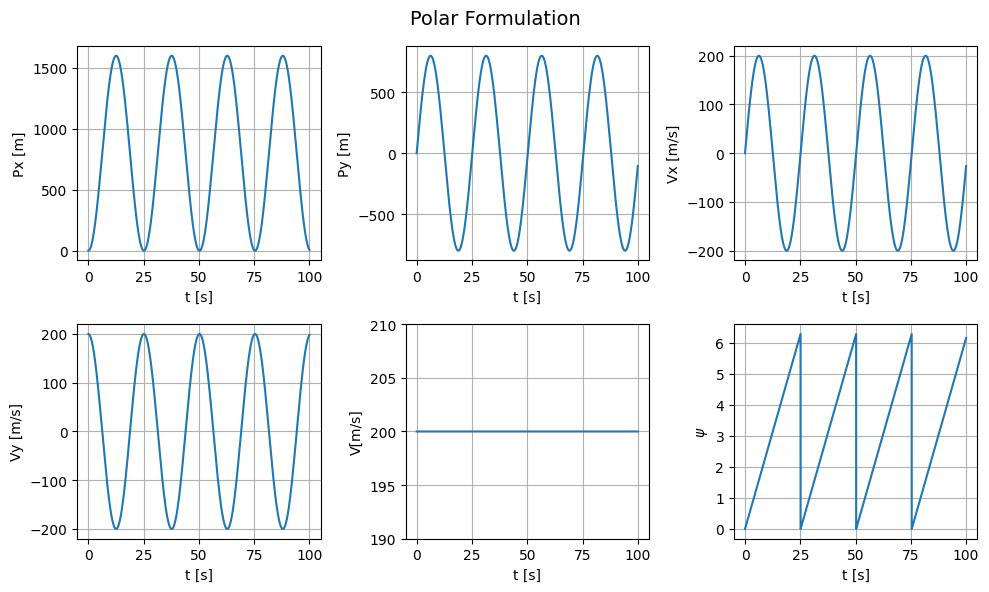

<Figure size 640x480 with 0 Axes>

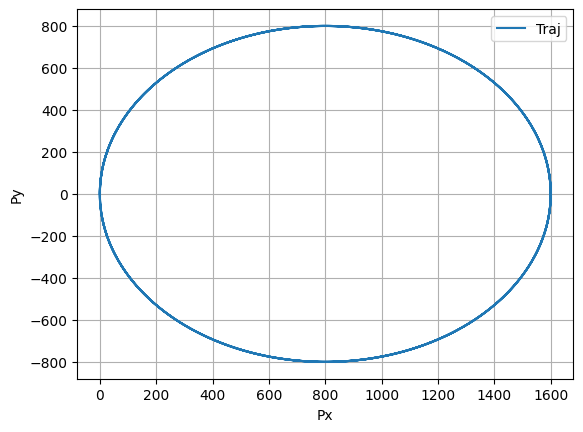

In [155]:
dt = 0.01
T  = 100.0


# --- 시뮬레이션 루프 ---
X = np.zeros((len(t), 4))
X[0] = x_0
f = make_f(a)
t, y = runge_kutta4(f, [0, T], x_0, dt)

# 결과 추출
Px = y[:, 0]
Py = y[:, 1]
V_result = y[:, 2]
psi = y[:, 3]

psi = psi % (2 * np.pi)

Vx = V_result*np.sin(psi)
Vy = V_result*np.cos(psi)

# 플롯
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
data   = [Px, Py, Vx, Vy, V_result ,psi]
labels = ['Px [m]', 'Py [m]', 'Vx [m/s]', 'Vy [m/s]', 'V[m/s]', r"$\psi$"]


fig.suptitle('Polar Formulation', fontsize=14)
for ax, d, label in zip(axes.flat, data, labels):
    if label == 'V[m/s]':
        ax.set_ylim(190, 210)
    ax.plot(t, d)
    ax.set_ylabel(label)
    ax.set_xlabel('t [s]')
    ax.grid(True)


plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

plt.plot(Px, Py, label = 'Traj')
plt.xlabel('Px')
plt.ylabel('Py')
plt.grid(True)
plt.legend()
plt.show()
